# Part C — Where the asset class is going (closing slides)

Thin driver notebook: all logic lives in `src/future/`. Every claim about the future is grounded in a scraped forward-looking dataset — registrations, rulemaking, litigation, product pipeline, retail attention. No punditry, no forecasting model.

- **Product pipeline** (`scrape_product_pipeline.py`, `analysis_pipeline.py`): EDGAR full-text search for fund-registration filings (N-2/485APOS/N-1A) mentioning CLOs — 293 filings, 102 distinct sponsors observed.
- **Composition shift** (`scrape_mm_share.py`, `analysis_composition_shift.py`): **not** the originally planned market-wide BSL-vs-MM new-issue share — Section 5's presale corpus (the intended source) is empty (S&P Akamai-walled, Fitch client-rendered). Reuses this project's own NPORT-P CLO-equity holdings instead, classified by a hand-curated middle-market manager-shelf keyword list — a narrower lens (two funds' own books), labeled as such.
- **Legal regime** (`scrape_litigation.py`, `analysis_legal_regime.py`): CourtListener/RECAP docket counts for the LME-era's public query terms (uptier, drop-down, liability management exercise). The planned joins against presale LME vocabulary and realized downgrade actions are both gapped for the same Section 5 reason — reported, not dropped.
- **Rulemaking**: `scrape_rulemaking.py` (Federal Register API) doubles as Section 6 v2's regulator-corpus input and this section's rulemaking/comment-controversy proxy.
- **Retail attention**: Google Trends (`scrape_trends.py`, via pytrends) — the one genuinely multi-year input in the maturation scorecard.
- **Market maturation scorecard** (`analysis_maturation_scorecard.py`): built as a **current-state snapshot**, not an indexed multi-year trend — most inputs (ETF AUM, TRACE volume, EFA holder composition) are themselves single-date snapshots elsewhere in this project; only Trends has real multi-year history.
- **Scenario watchlist** (`analysis_scenarios.py`): three macro scenarios, each paired with which already-built series in this project would move first — a monitoring map, explicitly not a forecast.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.future import (
    scrape_product_pipeline, scrape_mm_share, scrape_litigation, scrape_rulemaking,
    scrape_trends, scrape_etf_filings_options,
    analysis_pipeline, analysis_composition_shift, analysis_legal_regime,
    analysis_maturation_scorecard, analysis_scenarios,
    viz_pipeline, viz_composition, viz_legal, viz_scorecard, viz_watchlist,
    ledger,
)


/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_product_pipeline.run()
    scrape_mm_share.run()          # classifies cef_clo_positions.parquet, no new network calls
    scrape_litigation.run()
    scrape_rulemaking.run()
    scrape_trends.run()
    scrape_etf_filings_options.run()


## Analysis (interim -> final)

In [3]:
pipeline = analysis_pipeline.run()
composition_shift = analysis_composition_shift.run()
legal_regime = analysis_legal_regime.run()
maturation_scorecard = analysis_maturation_scorecard.run()
scenarios = analysis_scenarios.run()


## Viz (final -> figures/)

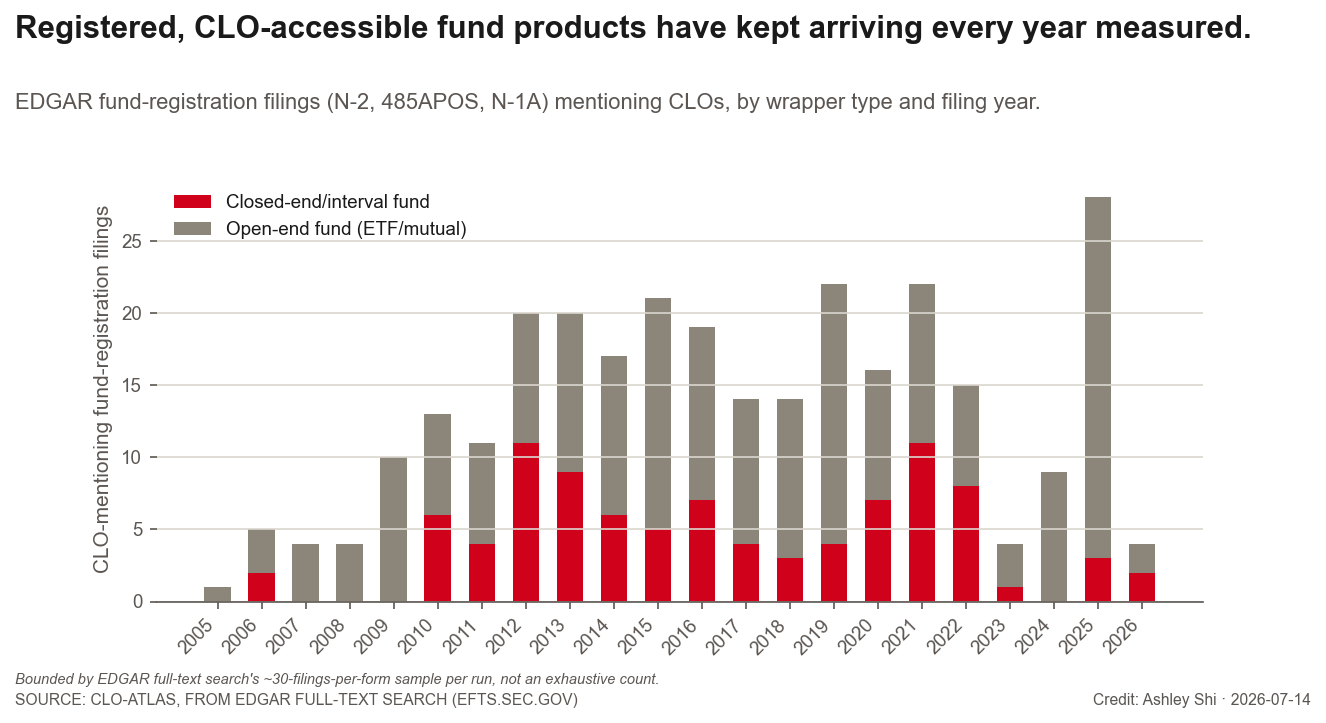

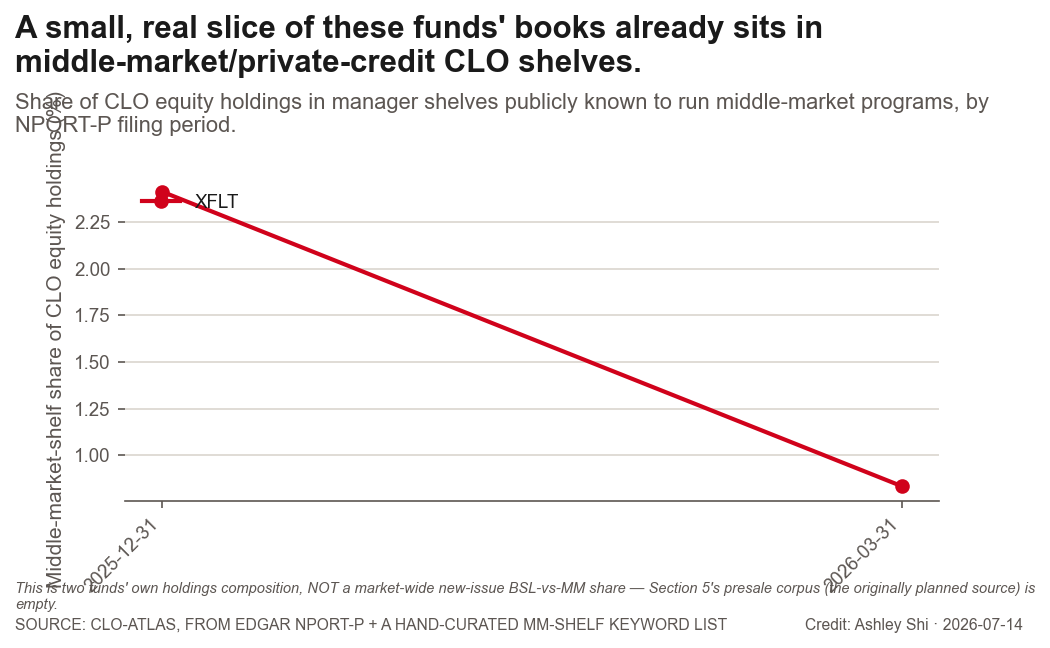

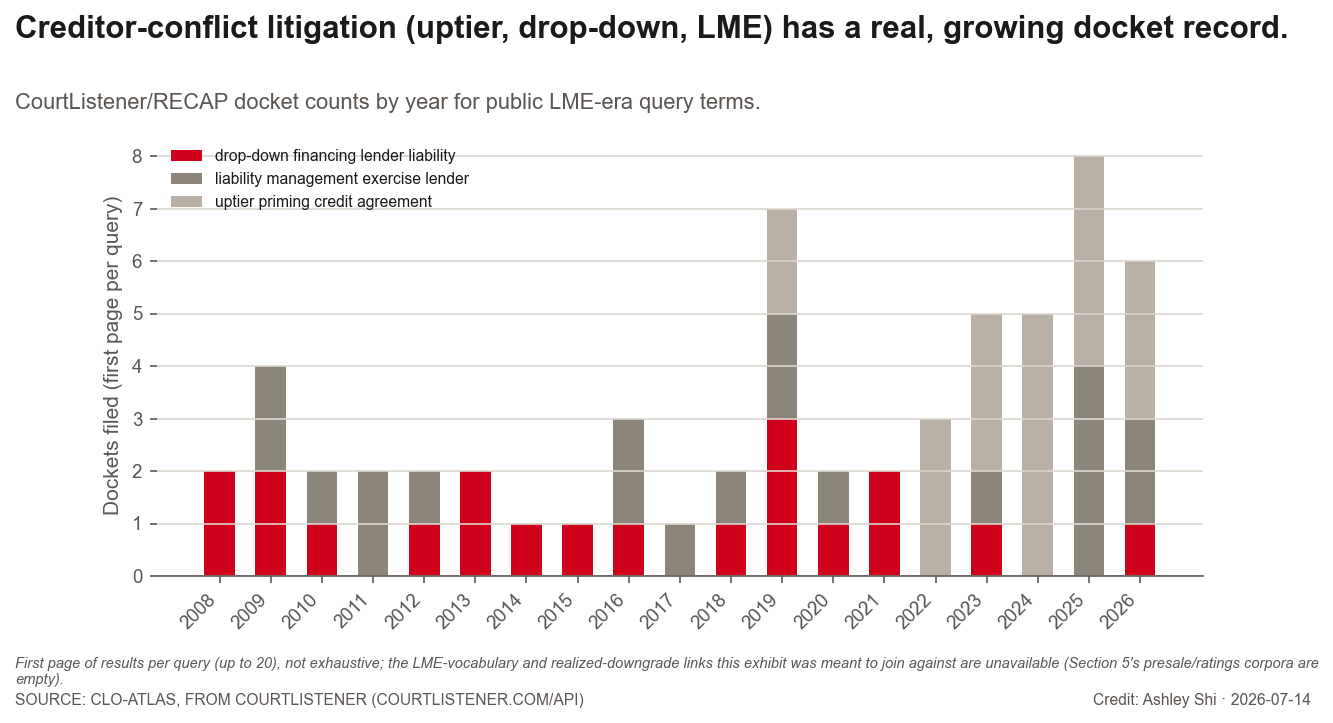

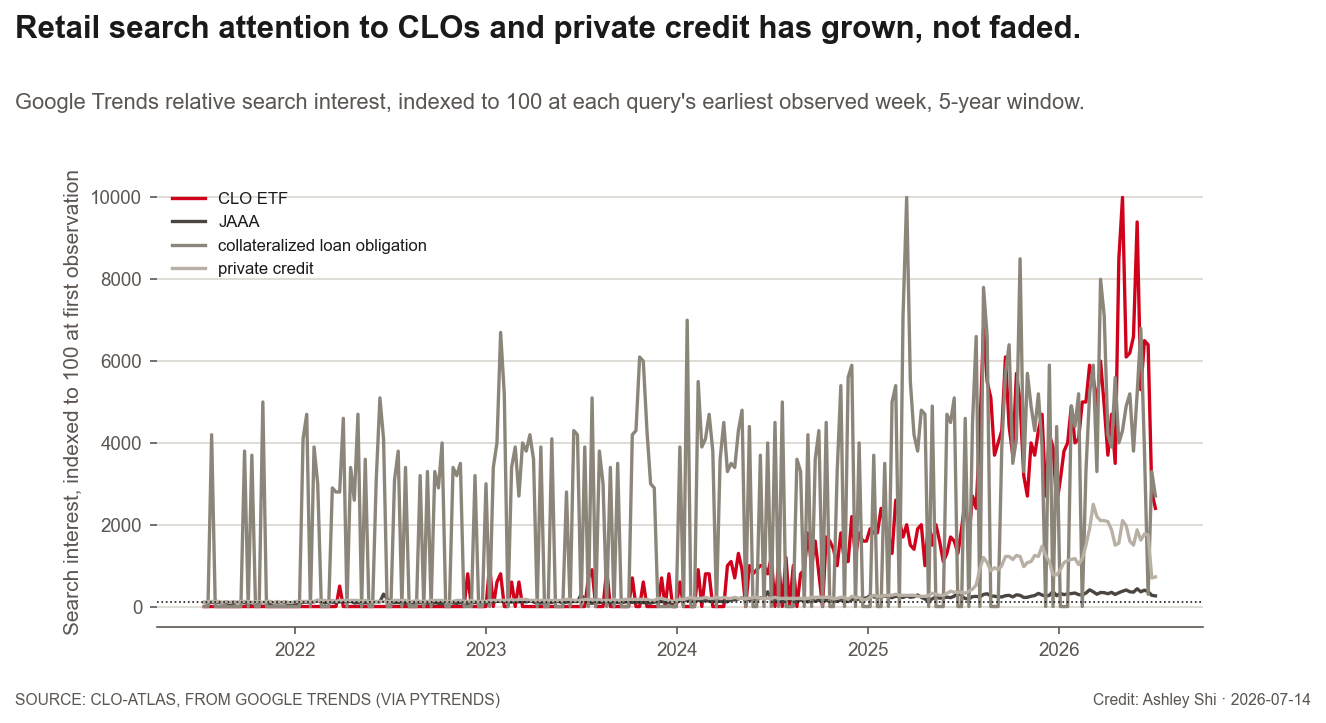

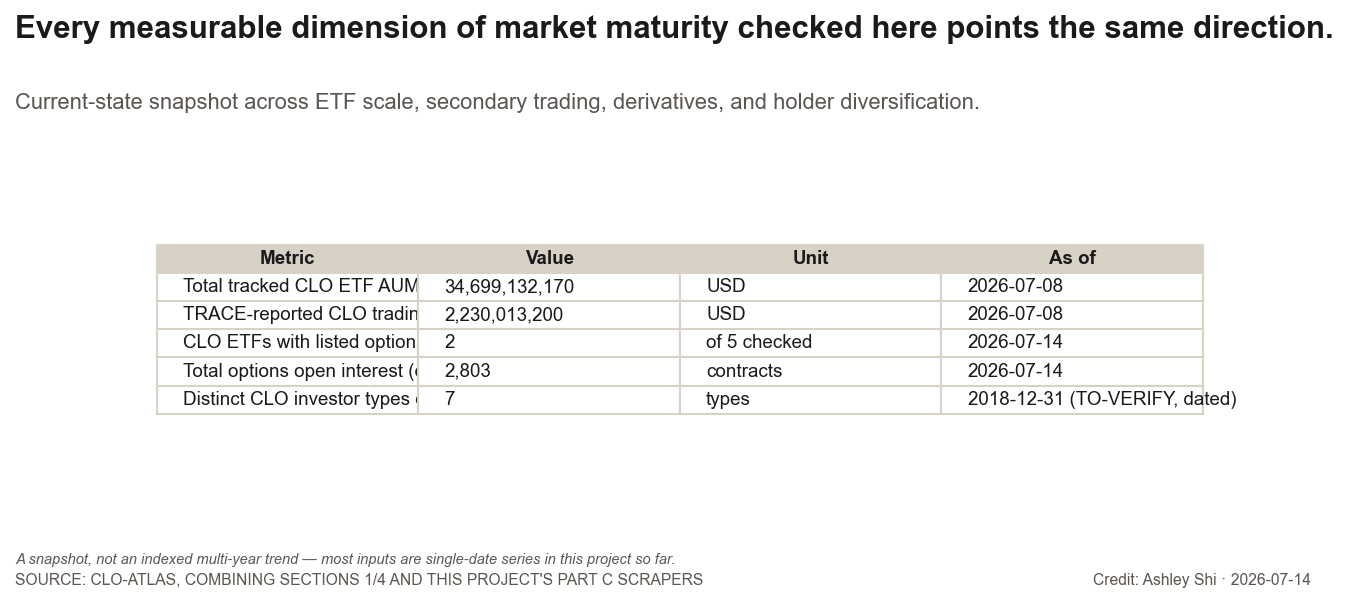

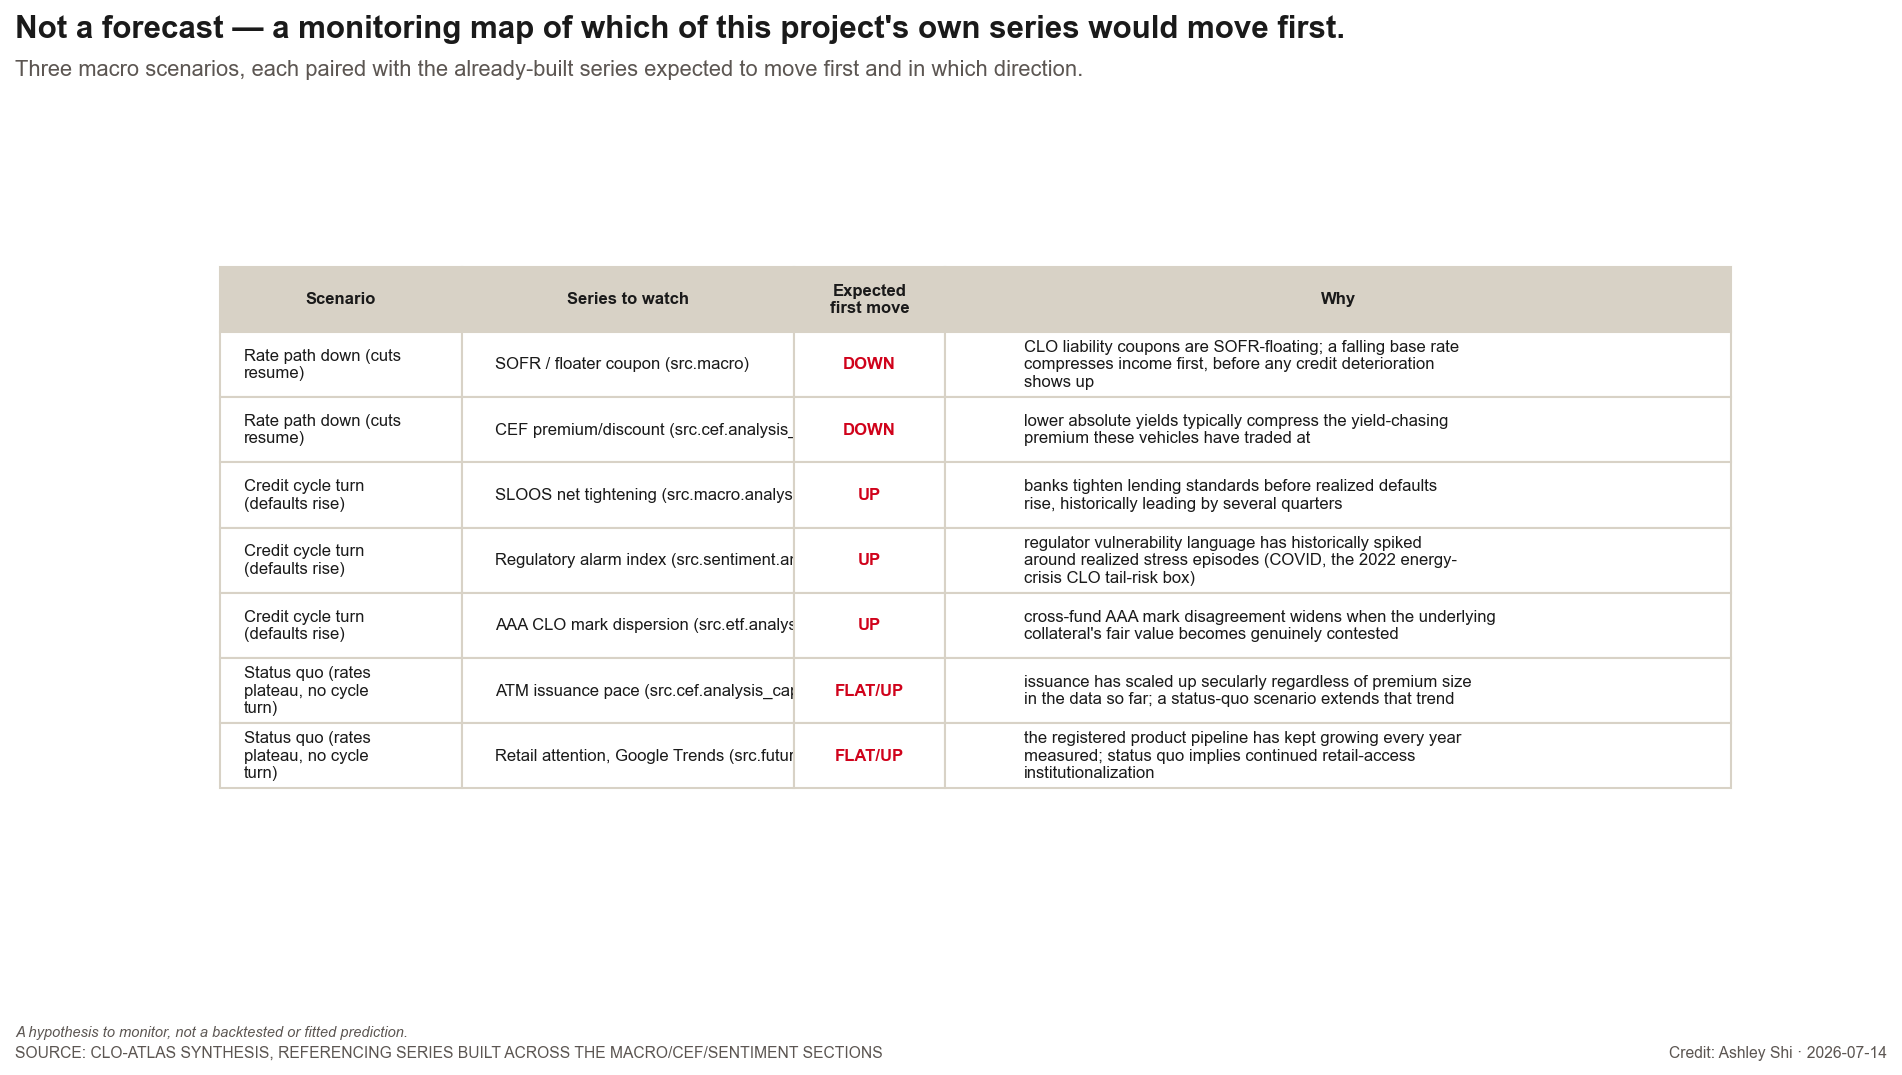

In [4]:
viz_pipeline.run()
viz_composition.run()
viz_legal.run()
viz_scorecard.run()
viz_watchlist.run()


## Exhibits

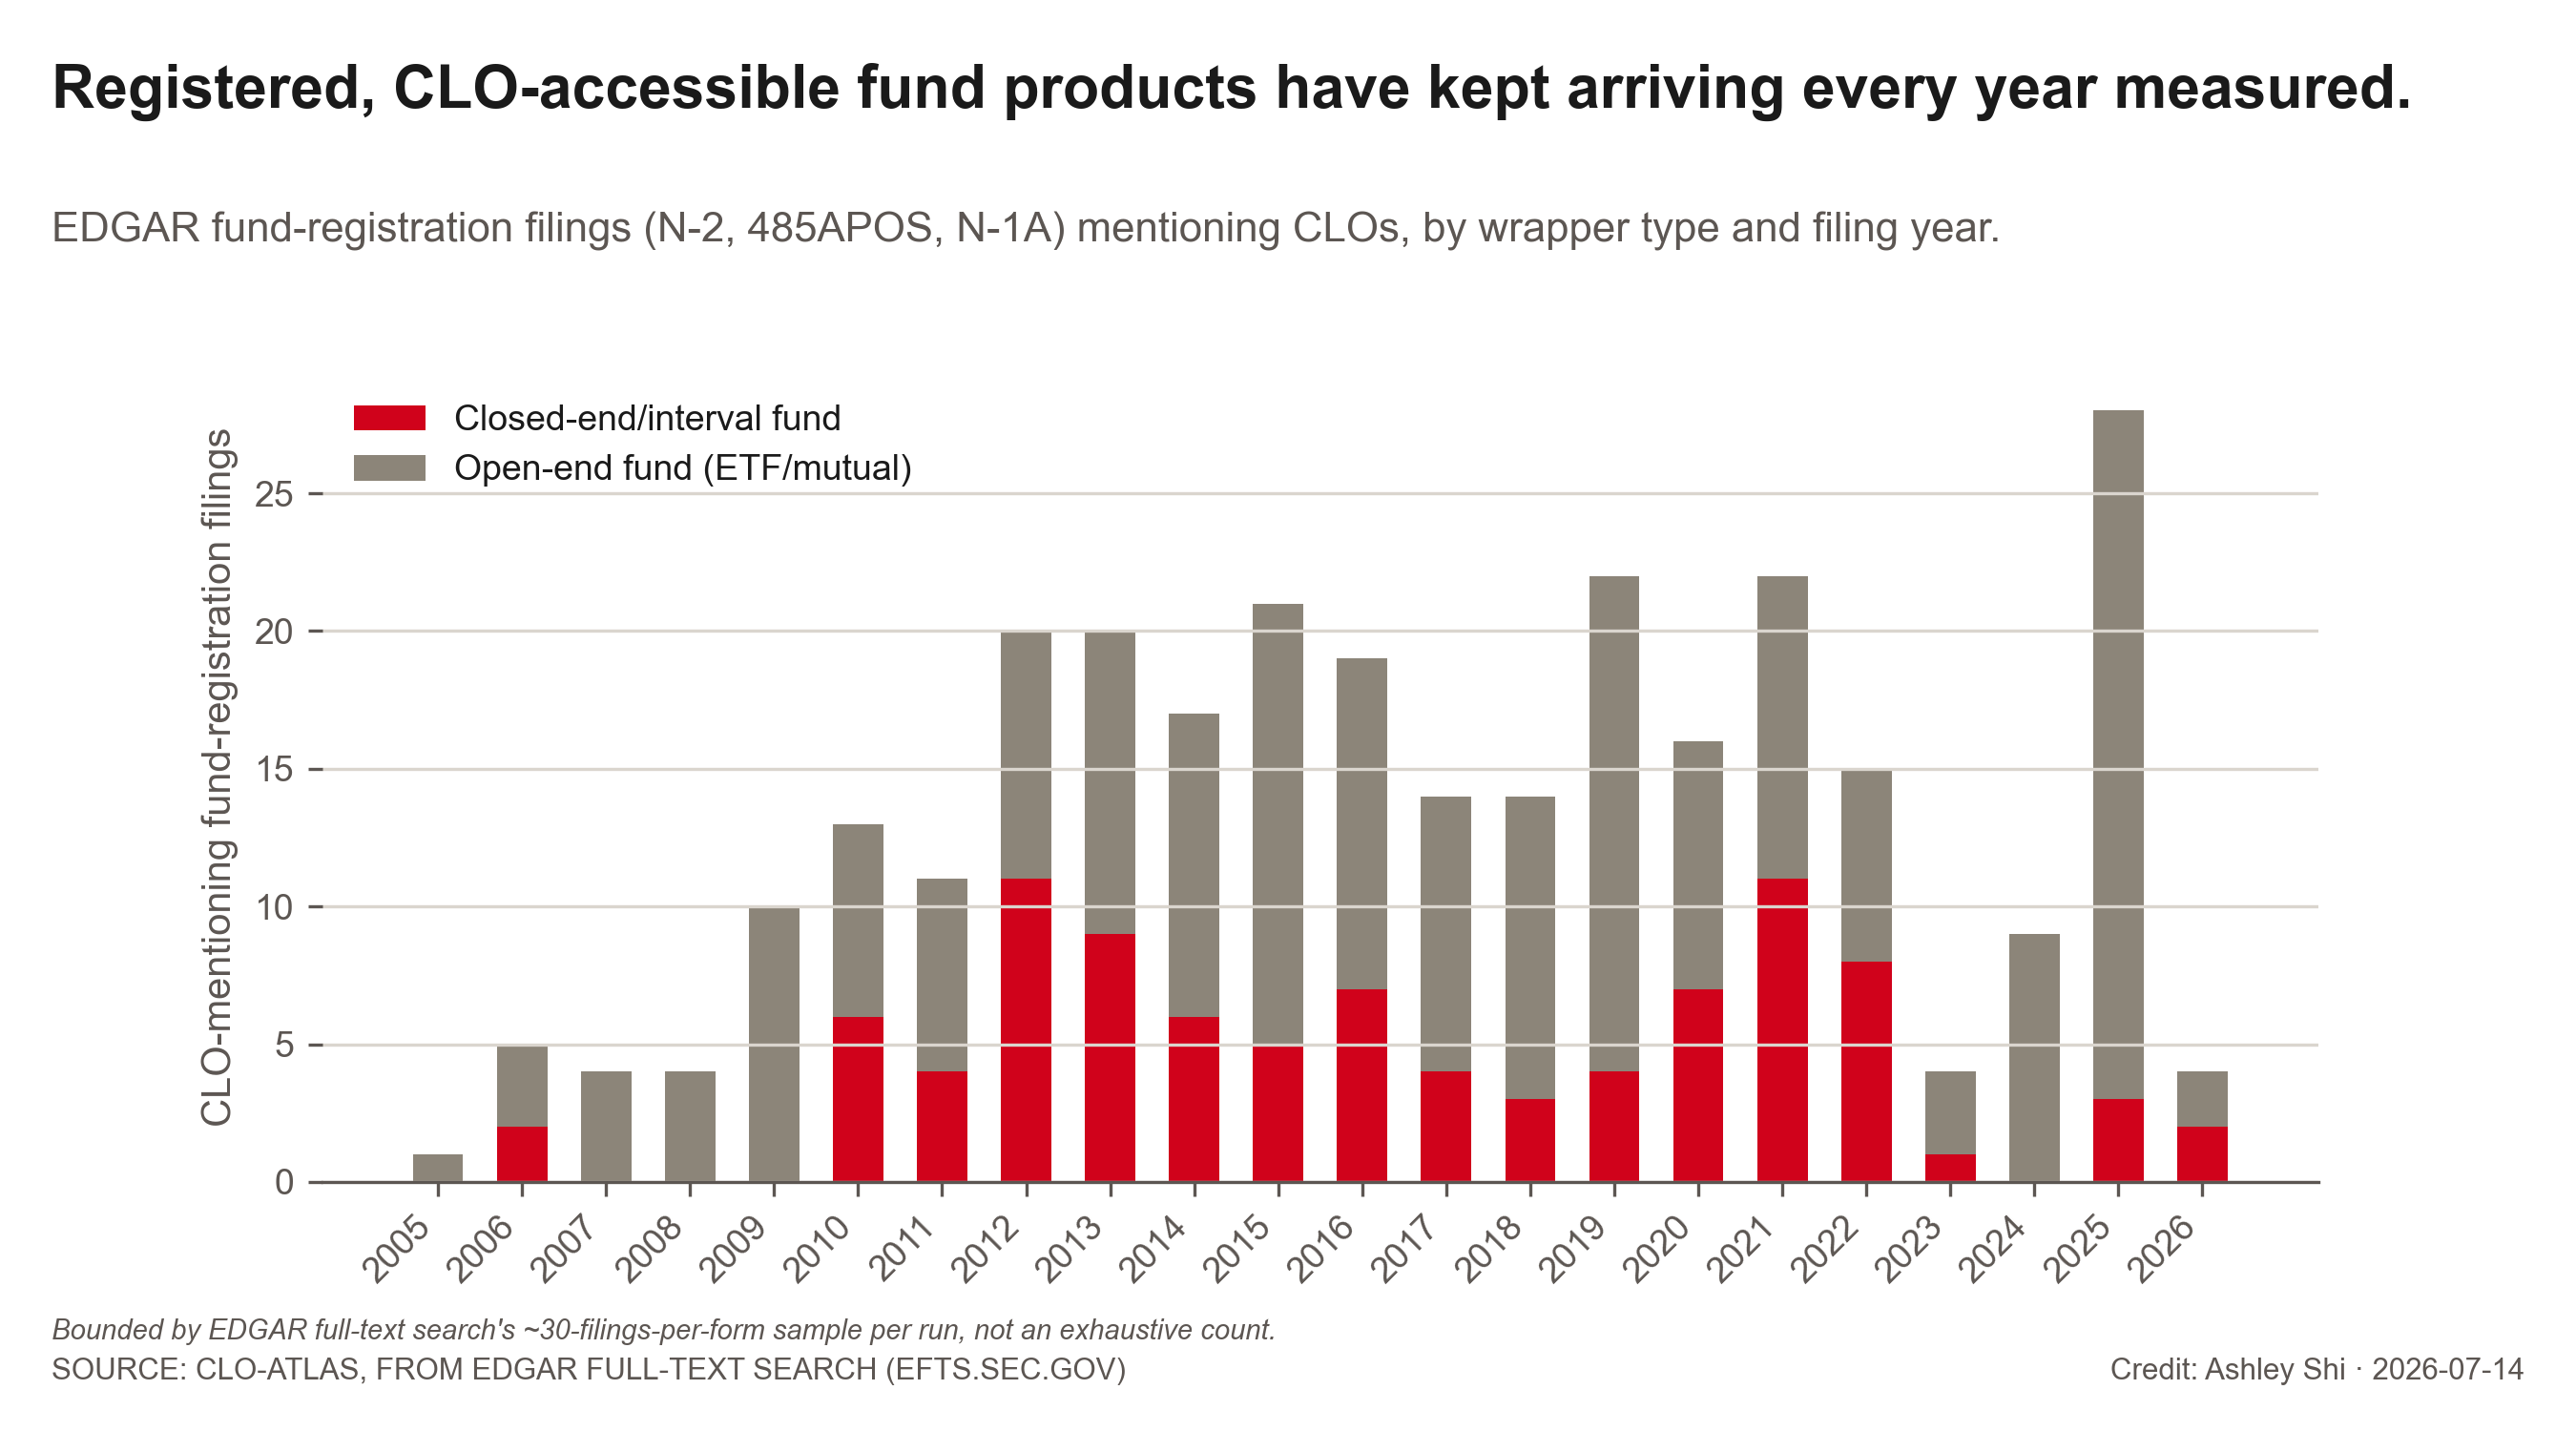

In [5]:
path = pathlib.Path("../figures") / "viz_registrations_by_year.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_registrations_by_year")


**VERIFIED** — EDGAR full-text search (`efts.sec.gov`, free/keyless) for fund-registration filings whose text mentions "collateralized loan obligation," scraped by `scrape_product_pipeline.py` and tallied by filing year in `analysis_pipeline.py`: 293 filings from 102 distinct sponsors across 2005–2026 (`docs/sources.md`).

The chart splits those filings by wrapper — N-2 closed-end/interval registrations versus 485APOS/N-1A open-end ETF and mutual-fund registrations — by filing year. The count sits in the single digits through the mid-2000s, settles into a sustained mid-teens-to-20s annual pace for most of the 2010s, and then jumps to nearly 30 filings in 2025, almost entirely open-end.

That is the access curve, not the asset curve: each filing is a new legal wrapper putting CLO exposure a brokerage click away from a retail or wealth-channel investor, and the 2025 spike is concentrated in exactly the fund type that reaches the broadest audience — the strongest evidence here that institutional access to CLOs is still actively widening, not plateauing. (EDGAR's ~30-filings-per-form-per-run sampling caps how high any single bar can read, so treat levels as a floor, not an exhaustive count.)

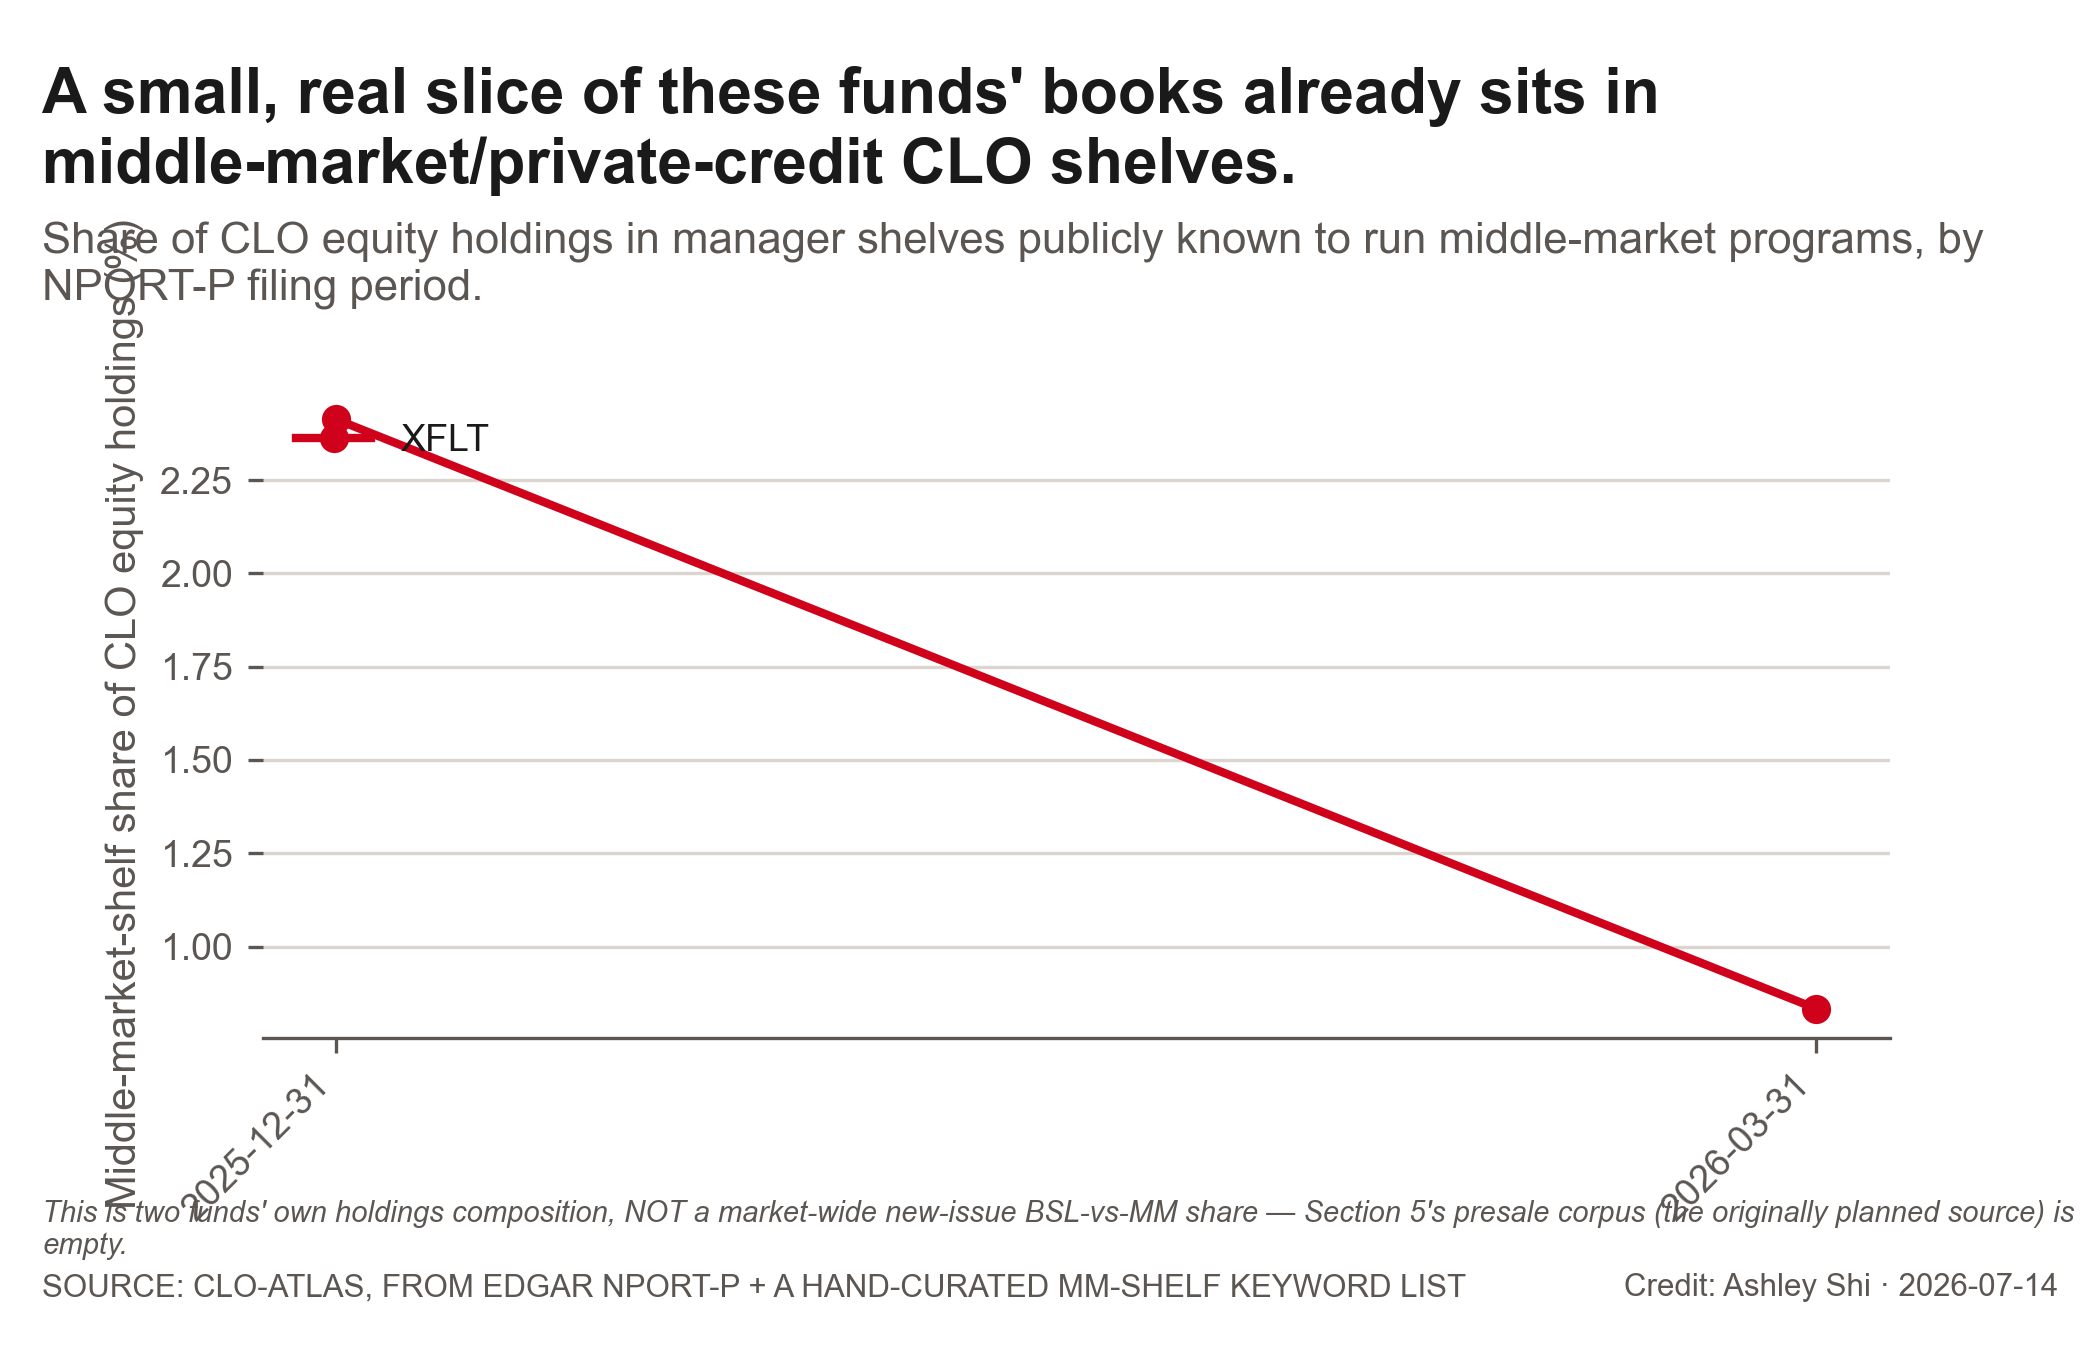

In [6]:
path = pathlib.Path("../figures") / "viz_mm_share_proxy.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_mm_share_proxy")


**VERIFIED** (computed here), but read the scope narrowly — this is **not** the market-wide broadly-syndicated-vs-middle-market new-issue share this section originally set out to build. Section 5's S&P/Fitch presale corpus, the intended source, is empty and logged in `docs/excluded_sources.md`; instead `scrape_mm_share.py` and `analysis_composition_shift.py` reclassify this project's own NPORT-P CLO-equity holdings data by a hand-curated list of manager shelves publicly known to run middle-market/private-credit CLO programs.

The line shown is XFLT's own middle-market-shelf share of its CLO equity book across the only two NPORT-P filing periods currently cached — and it *falls*, from about 2.4% at 2025-12-31 to 0.8% at 2026-03-31, the opposite of a "private credit is quietly eating CLO share" story.

For the closing slide, the honest framing is a stated gap, not a supporting data point: this project can currently measure middle-market penetration only through one fund's book over two quarters, and even that narrow proxy doesn't yet corroborate the secular shift the registration-pipeline and attention exhibits otherwise suggest — worth naming as unresolved rather than smoothed over.

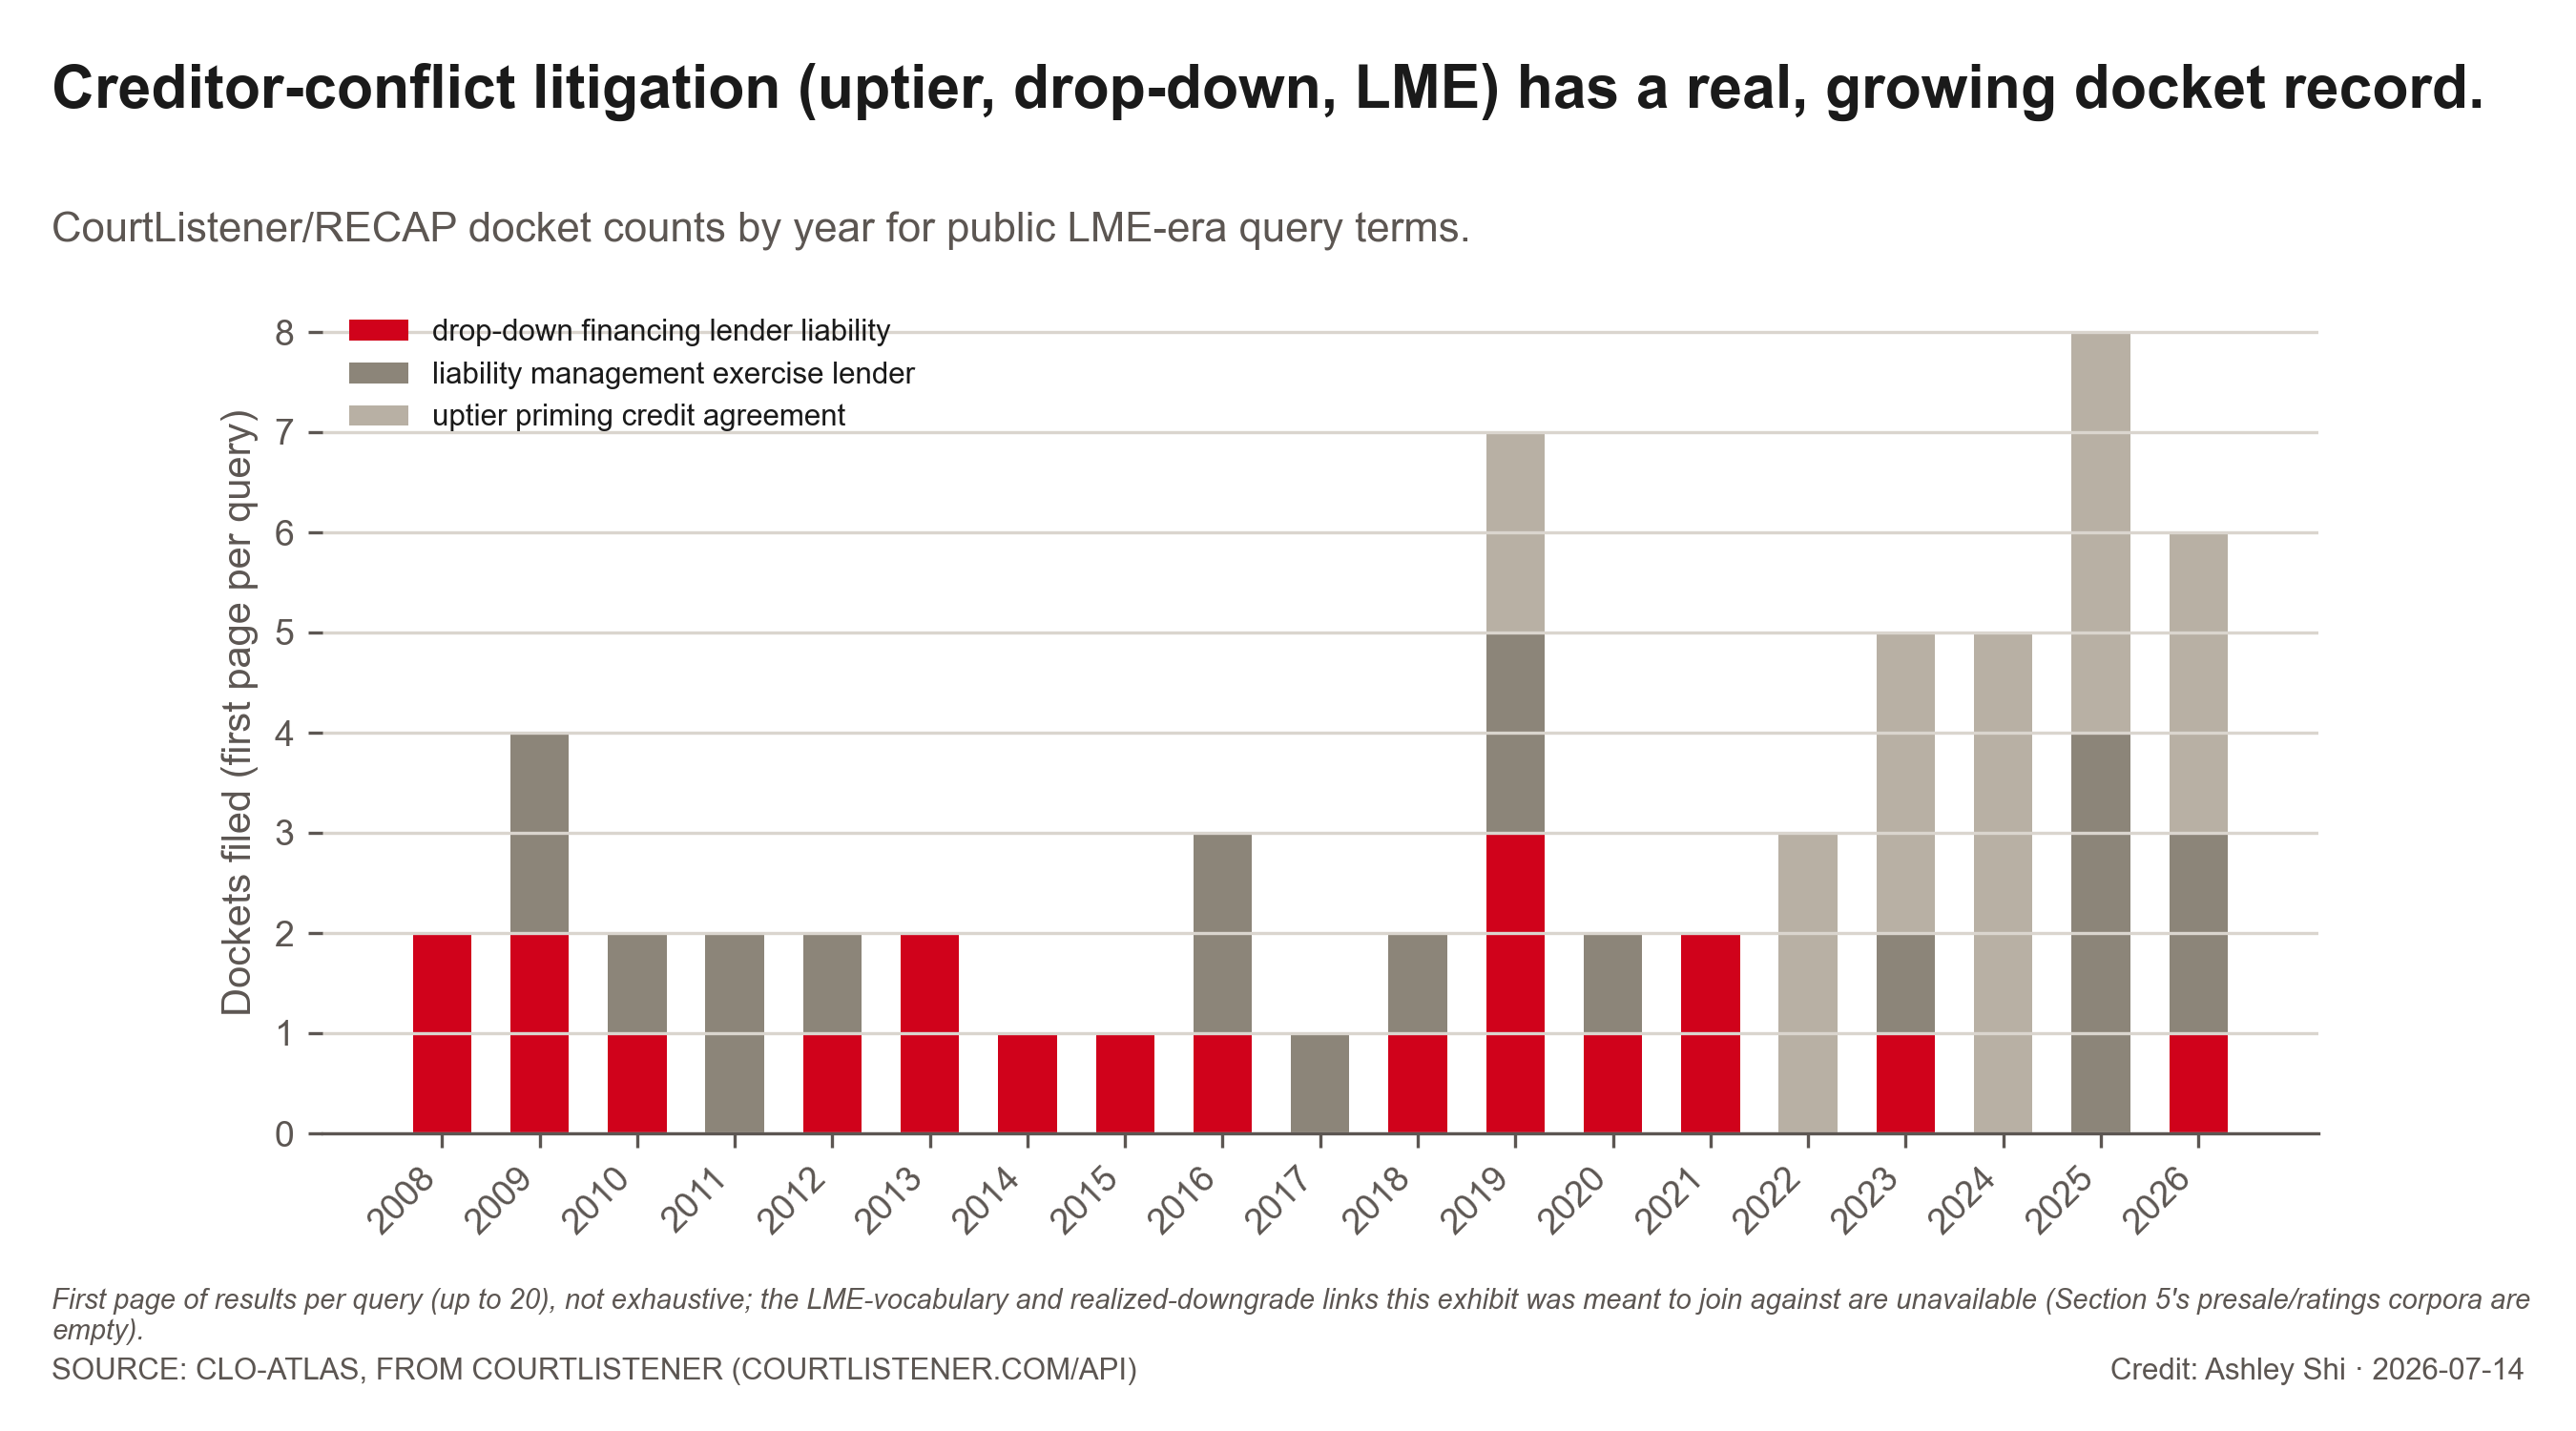

In [7]:
path = pathlib.Path("../figures") / "viz_litigation_intensity.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_litigation_intensity")


**VERIFIED** — CourtListener/RECAP docket search (`courtlistener.com/api`, free/keyless) for three LME-era query terms (uptier/priming, drop-down financing, liability management exercise), scraped by `scrape_litigation.py` and tallied by filing year in `analysis_legal_regime.py`: 60 dockets across the three terms, 2008–2026.

The chart stacks docket counts by year and query term. Filings run at a thin background rate of roughly 1–4 a year through 2018, then step up to a consistently higher band of 5–8 a year from 2023 on, with "uptier priming credit agreement" — the most aggressive form of the creditor-on-creditor fight — becoming the dominant category from 2022 onward.

For a market this dependent on creditor rights holding up as designed, that is the legal regime CLOs are actually operating in going forward: a real and growing docket record, not a hypothetical tail risk. The joins this exhibit was meant to make — to presale LME vocabulary and to realized rating downgrades — are both stated GAPs (Section 5's presale and ratings corpora are empty for the same reason), so this shows litigation volume rising, not yet whether it is translating into realized CLO collateral losses.

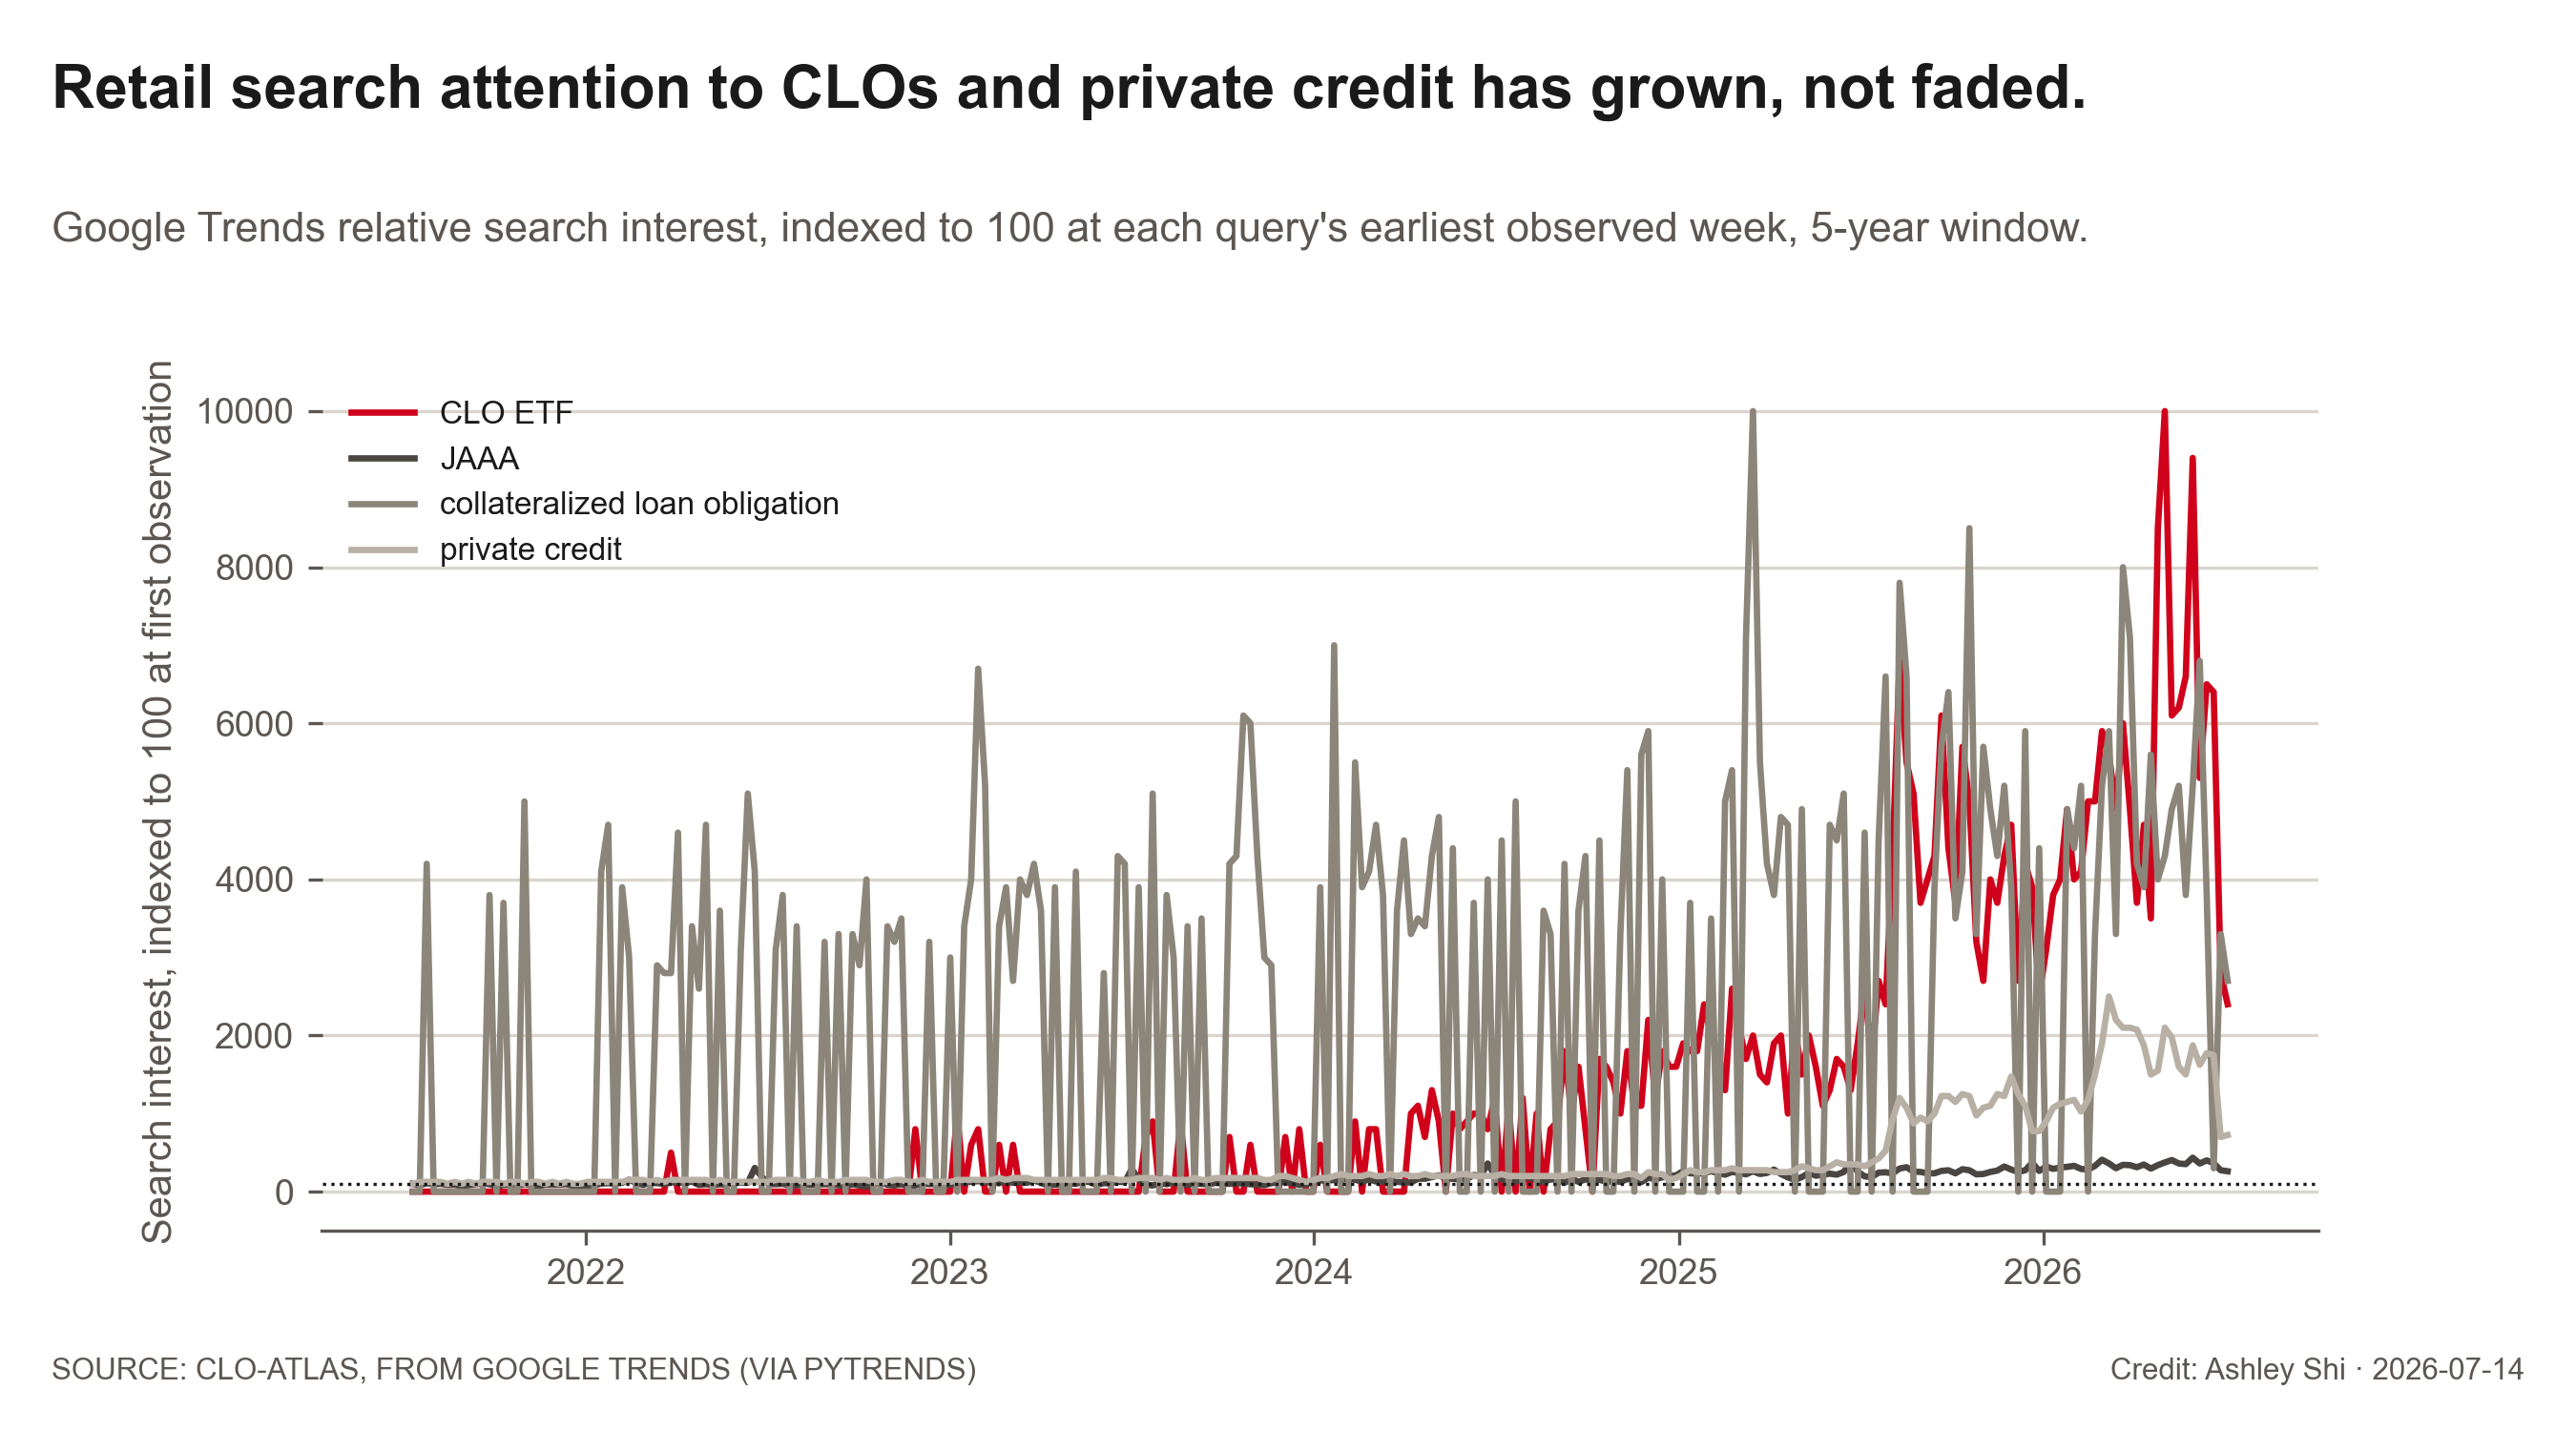

In [8]:
path = pathlib.Path("../figures") / "viz_attention_indexed.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_attention_indexed")


**VERIFIED** — Google Trends relative search interest via `pytrends` (`trends.google.com`), scraped by `scrape_trends.py` and indexed to 100 at each query's own first observed week in `analysis_maturation_scorecard.py`'s `trends_indexed()`; four queries ("CLO ETF," "JAAA," "collateralized loan obligation," "private credit"), weekly, 2021–2026.

All four series trend up over the window, with a visibly sharper acceleration starting in 2025 that carries into 2026 — most cleanly in "private credit," which climbs from a low-hundreds index level to the thousands by early 2026.

That is the retail/media-attention leg of the maturation story, and it is moving in the same direction as the registration pipeline and the litigation record: growing, not fading, right as the asset class is also becoming more accessible and more legally contested. Read direction here, not exact multiples — the "CLO ETF" and generic "collateralized loan obligation" lines are visually noisy because several early weeks recorded near-zero raw interest, which inflates the indexed ratio once search volume ticks up at all.

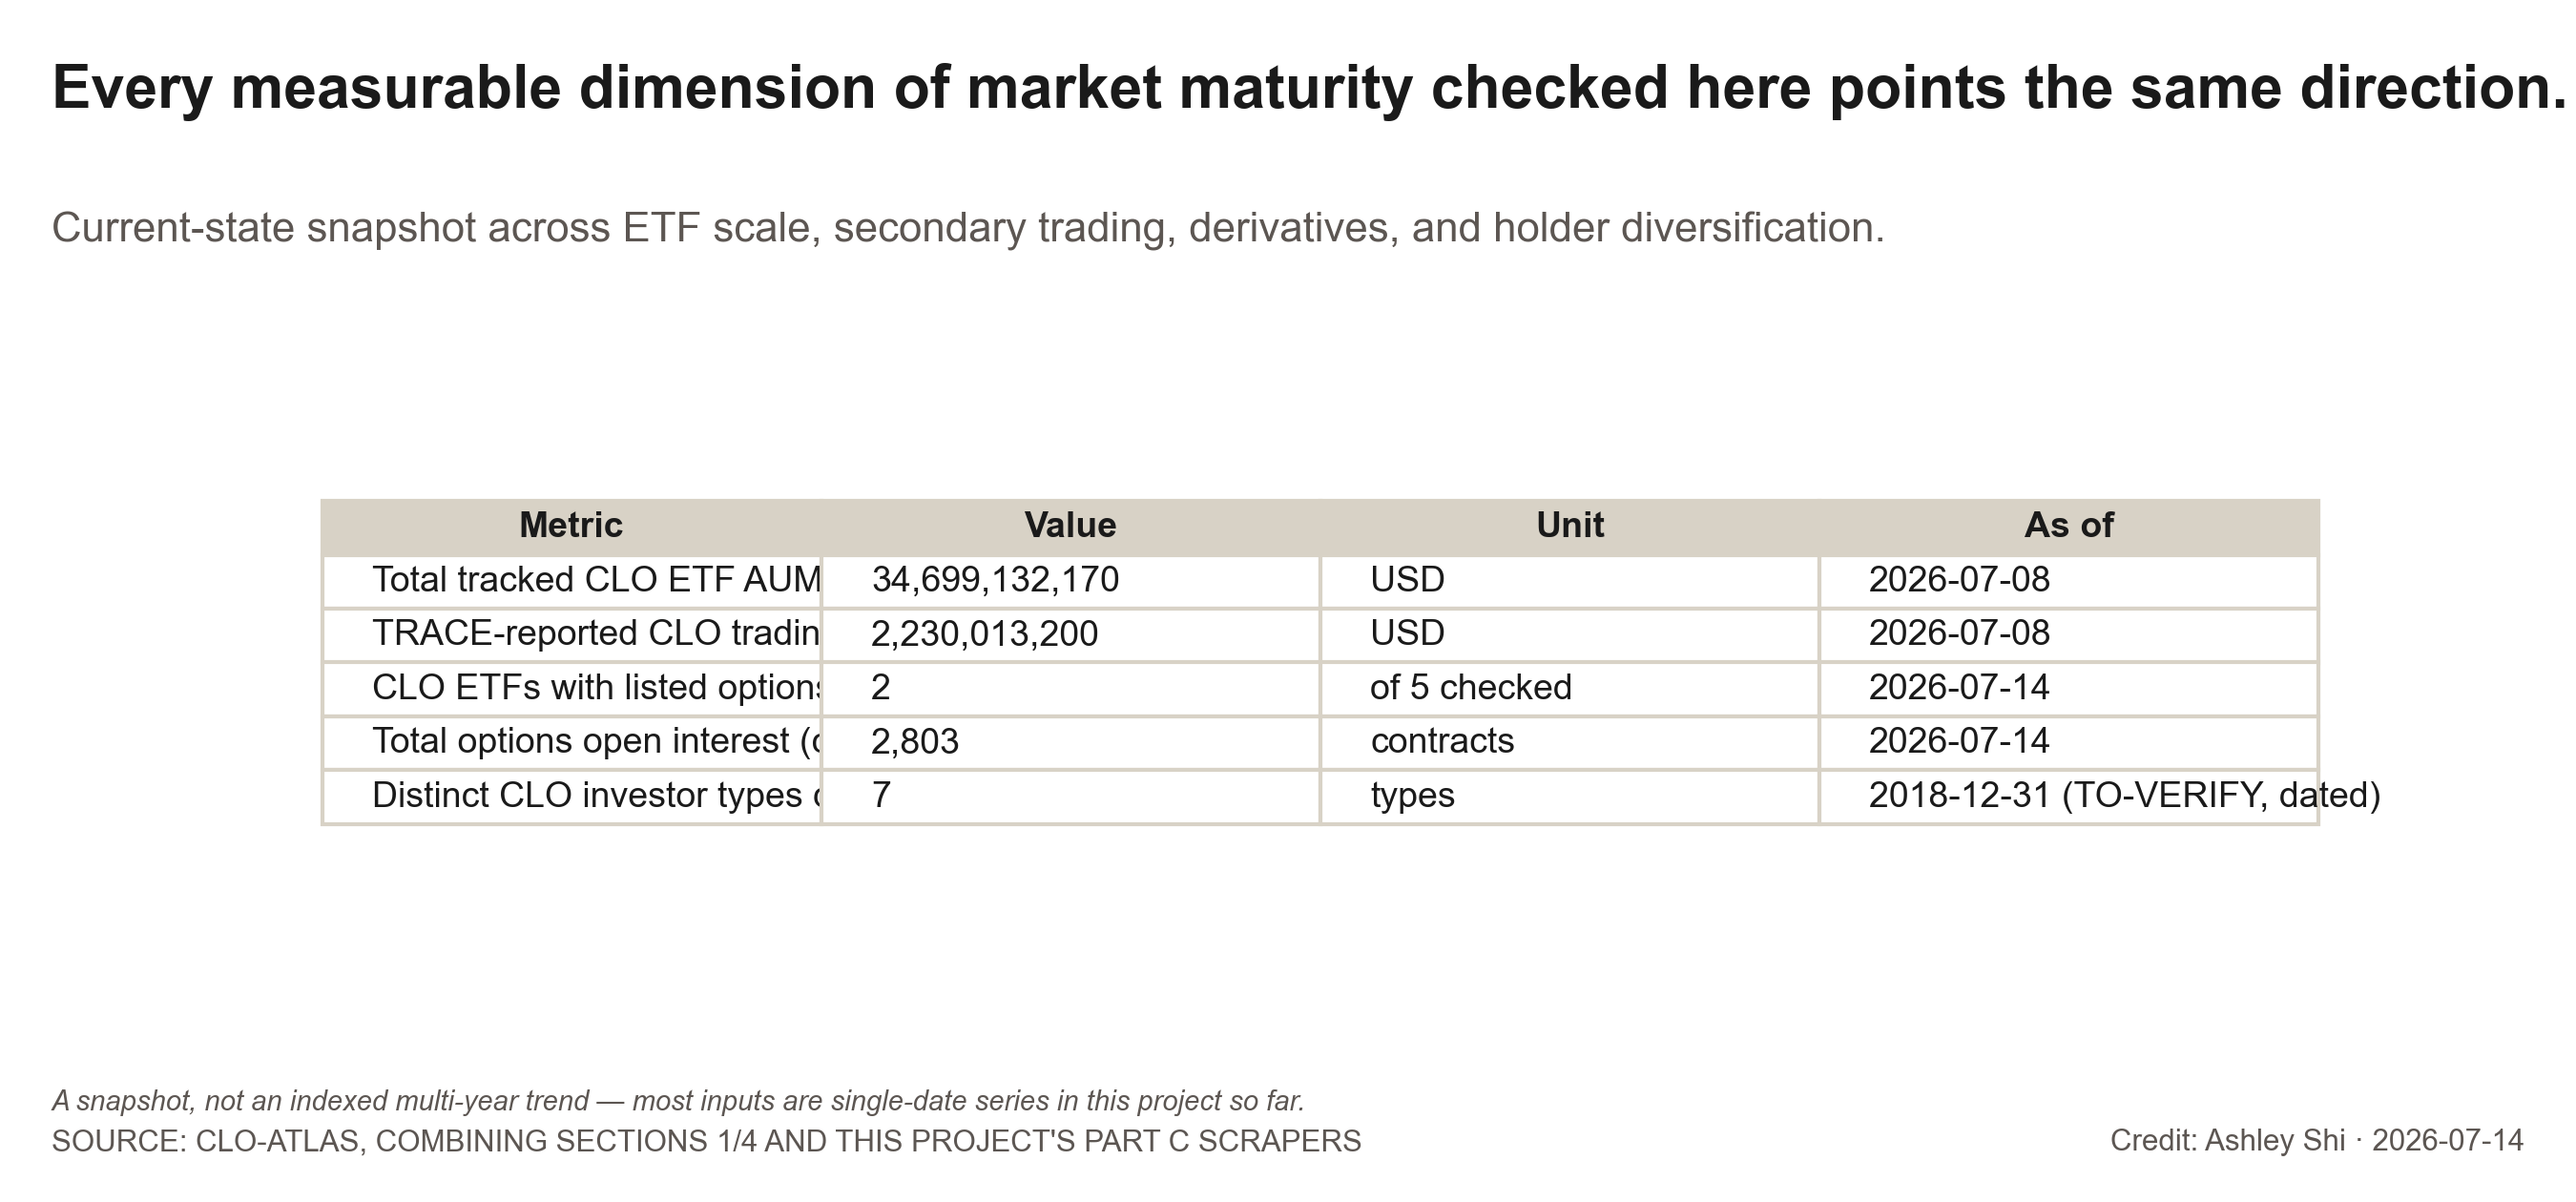

In [9]:
path = pathlib.Path("../figures") / "viz_scorecard_table.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_scorecard_table")


**VERIFIED**, row by row, combining Sections 1 and 4 with this section's own scrapers (`analysis_maturation_scorecard.py`) — one exception flagged below. As of 2026-07-08: total tracked CLO ETF AUM is $34.70B and TRACE-reported CLO trading volume is $2.23B. As of 2026-07-11: 2 of 5 checked CLO ETFs have listed options, with 2,803 contracts of total open interest. The fifth row, 7 distinct CLO investor types disclosed, is **TO-VERIFY** and dated — it comes from a Fed FEDS note as of 2018-12-31, by far the oldest input on the table.

Rather than a chart, this is a table-graphic snapshot: one row each for ETF scale, secondary-market trading, derivatives depth, and holder diversification, deliberately not forced into an indexed multi-year trend because most of these inputs are single-date snapshots elsewhere in this project so far.

It is the closing slide's "how mature is this market right now" frame — four independent maturity signals, from four different data sources, all pointing toward a market with real scale, real secondary liquidity, and real (if thin) derivatives infrastructure, with the one caveat that the holder-diversification figure needs a fresher source before it can carry real weight.

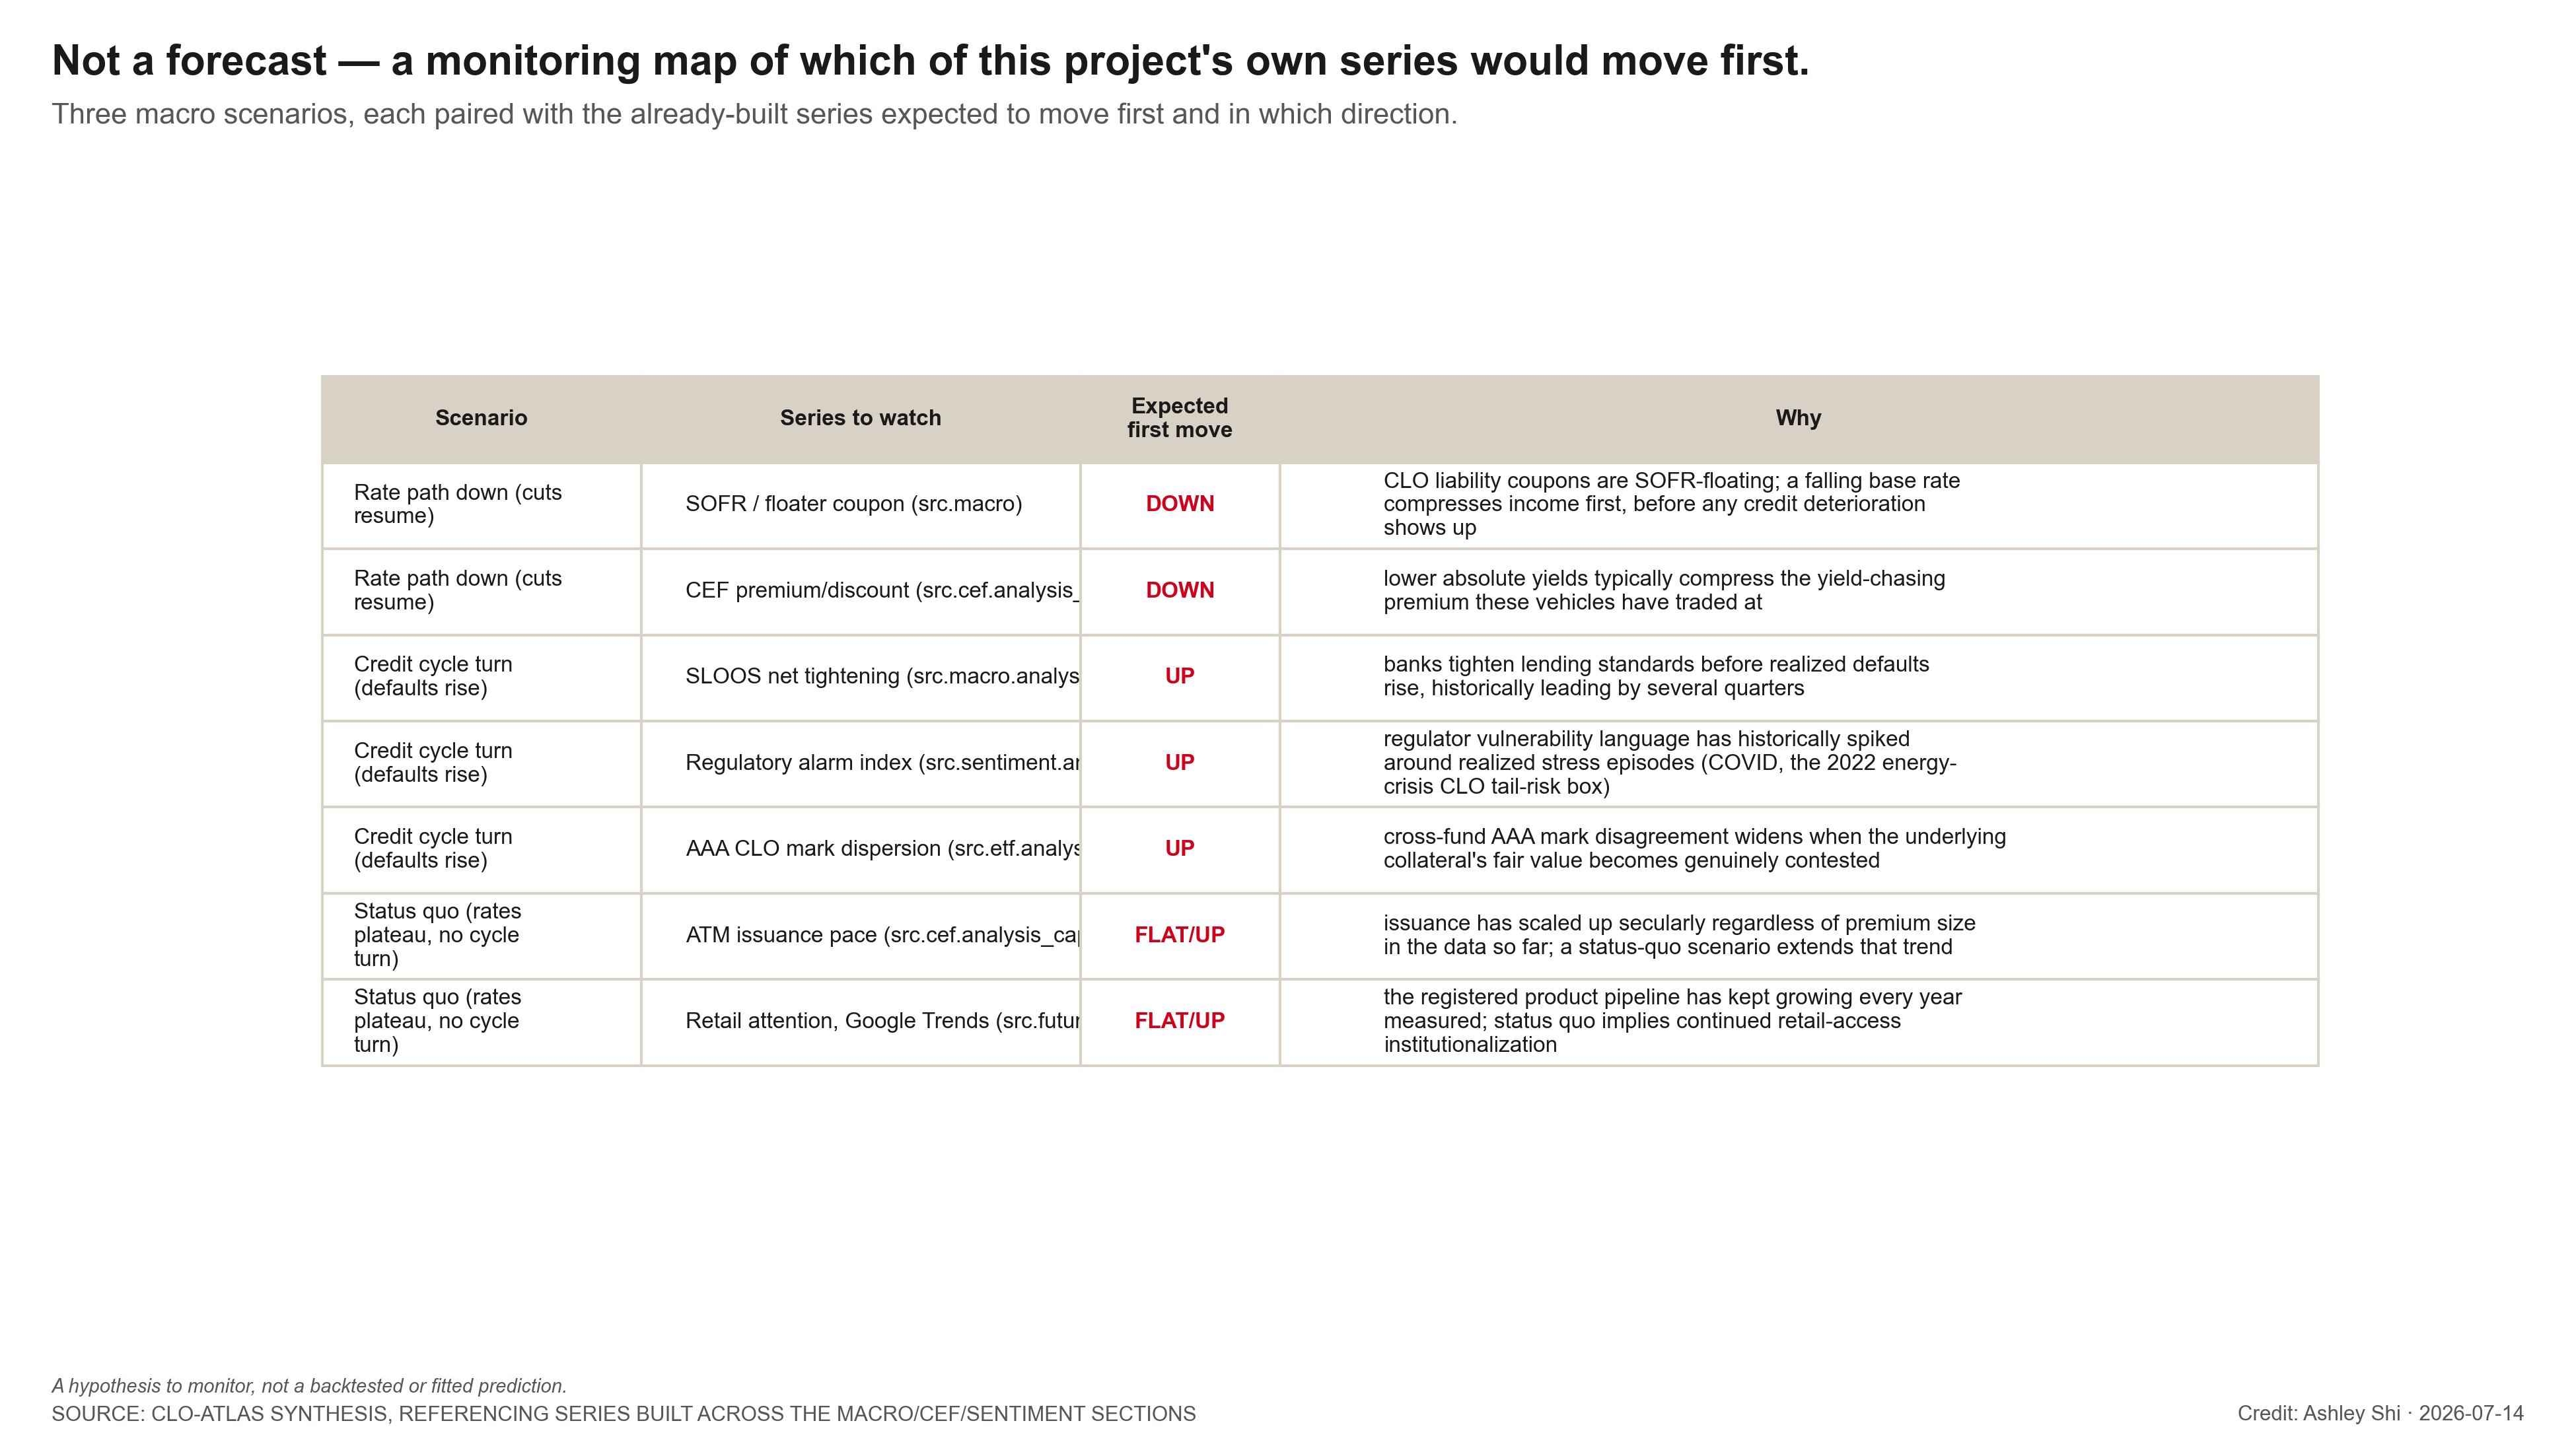

In [10]:
path = pathlib.Path("../figures") / "viz_scenario_watchlist.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_scenario_watchlist")


**VERIFIED** as a monitoring construct — explicitly **not** a forecast. `analysis_scenarios.py` builds a 7-row watchlist across 3 macro scenarios (rate cuts resume, credit cycle turn/defaults rise, status quo), each row pointing to an already-built series elsewhere in this project and the direction it should move first.

The table maps, for example, SOFR/floater coupons and CEF premiums down if rate cuts resume; SLOOS net tightening, the regulatory alarm index, and AAA CLO mark dispersion up if the credit cycle turns; and ATM issuance pace plus retail search attention flat-to-up in a status-quo path — each paired with a one-line rationale grounded in how CLO structures and this project's own data actually behave.

This is deliberately the last exhibit: instead of guessing where CLOs go from here, it hands the audience a concrete instrument panel — specific, already-tracked numbers to watch, and which direction each one moving first would confirm which scenario is playing out.

## VERIFIED / TO-VERIFY ledger

Every number appearing in this section's exhibits, including the composition-shift and legal-regime chains' stated gaps.

In [11]:
future_ledger = ledger.run()
future_ledger


,value,computation_or_citation,as_of,tag
0,293 CLO-mentioning fund-registration filings a...,"analysis_pipeline.registrations_by_year(), fro...",n/a,VERIFIED
1,102 distinct sponsors observed in the registra...,analysis_pipeline.sponsor_entry_order(),n/a,VERIFIED
2,MM-shelf share proxy: 2 fund-period observatio...,analysis_composition_shift.mm_share_trend() — ...,n/a,VERIFIED
3,60 LME-era dockets found across 3 query terms,"analysis_legal_regime.litigation_intensity(), ...",n/a,VERIFIED
4,Litigation intensity: measured,CourtListener docket counts by year (first pag...,n/a,VERIFIED
5,-> LME vocabulary in presales/ratings: GAP,Section 5 presale corpus is empty (S&P Akamai-...,n/a,GAP — not plotted
6,-> realized downgrade actions: GAP,ratings_transitions_monthly.parquet is empty f...,n/a,GAP — not plotted
7,Total tracked CLO ETF AUM: 34699132170.0,analysis_maturation_scorecard.snapshot_table(),2026-07-08,VERIFIED
8,TRACE-reported CLO trading volume: 2230013200.0,analysis_maturation_scorecard.snapshot_table(),2026-07-08,VERIFIED
9,CLO ETFs with listed options: 2.0,analysis_maturation_scorecard.snapshot_table(),2026-07-14,VERIFIED
